<a href="https://colab.research.google.com/github/jiho25-hl/ABCD-A/blob/20250515-1/yolo_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 중간고사 2.png to 중간고사 2.png
업로드된 이미지 파일: 중간고사 2.png

image 1/1 /content/중간고사 2.png: 1280x1280 3 cats, 6 dogs, 3 sports balls, 2 remotes, 20355.0ms
Speed: 13.5ms preprocess, 20355.0ms inference, 4.5ms postprocess per image at shape (1, 3, 1280, 1280)

✅ 최종 감지된 고양이 수: 3마리


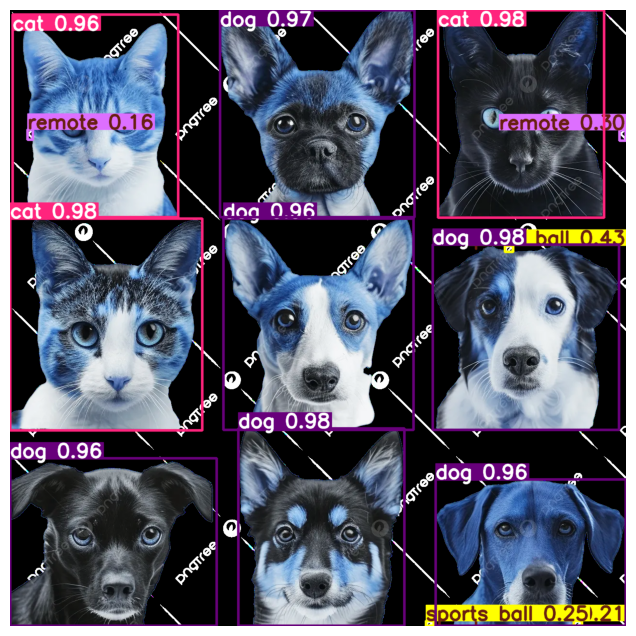

In [20]:
# 1. ultralytics 설치 (최초 1회)
!pip install ultralytics -q

# 2. 이미지 업로드
from google.colab import files
uploaded = files.upload()  # yolo1.jpg 등 이미지 선택

# 업로드된 이미지 파일 이름 가져오기
img_path = list(uploaded.keys())[0]
print(f"업로드된 이미지 파일: {img_path}")

# 3. YOLOv8 모델 로드 및 추론
from ultralytics import YOLO

# 가장 정확한 모델 사용 (yolov8x.pt)
model = YOLO('yolov8x.pt')

# 추론 실행 (conf=0.15, iou=0.6, imgsz=1280으로 정밀도 높임)
results = model(img_path, conf=0.15, iou=0.6, imgsz=1280)

# 클래스 이름 가져오기
names = model.names

# 감지된 박스 중 고양이만 필터링
cat_boxes = []
for box in results[0].boxes:
    cls_id = int(box.cls)
    label = names[cls_id]
    conf = float(box.conf)
    if label == 'cat':
        xyxy = box.xyxy.tolist()[0]  # [x1, y1, x2, y2]
        cat_boxes.append([*xyxy, conf])

# 중복 박스 제거 함수 (IoU 기준)
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_overlaps(boxes, iou_threshold=0.5):
    filtered = []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)  # 신뢰도 내림차순
    while boxes:
        chosen = boxes.pop(0)
        filtered.append(chosen)
        boxes = [b for b in boxes if iou(chosen, b) < iou_threshold]
    return filtered

filtered_cats = filter_overlaps(cat_boxes)

print(f"\n✅ 최종 감지된 고양이 수: {len(filtered_cats)}마리")

# 4. 결과 이미지 출력 (plot() 함수로 바로 이미지 가져오기)
import matplotlib.pyplot as plt

img_with_boxes = results[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(img_with_boxes)
plt.axis('off')
plt.show()

Saving 중간고사 2.png to 중간고사 2 (1).png
업로드된 이미지 파일: 중간고사 2 (1).png

image 1/1 /content/중간고사 2 (1).png: 1280x1280 3 cats, 6 dogs, 3 sports balls, 2 remotes, 20461.2ms
Speed: 13.4ms preprocess, 20461.2ms inference, 4.9ms postprocess per image at shape (1, 3, 1280, 1280)

✅ 최종 감지된 고양이 수: 3마리


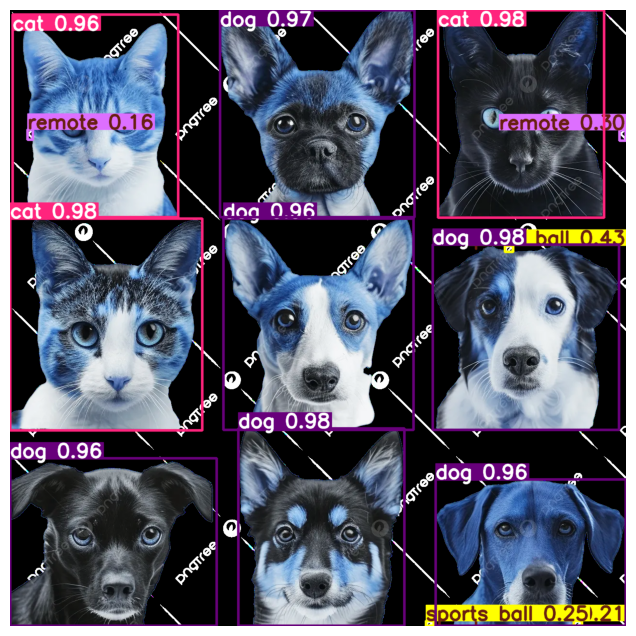

In [21]:
# 1. ultralytics 설치 (최초 1회)
!pip install ultralytics -q

# 2. 이미지 업로드
from google.colab import files
uploaded = files.upload()  # yolo1.jpg 등 이미지 선택

# 업로드된 이미지 파일 이름 가져오기
img_path = list(uploaded.keys())[0]
print(f"업로드된 이미지 파일: {img_path}")

# 3. YOLOv8 모델 로드 및 추론
from ultralytics import YOLO

# 가장 정확한 모델 사용 (yolov8x.pt)
model = YOLO('yolov8x.pt')

# 추론 실행 (conf=0.15, iou=0.6, imgsz=1280으로 정밀도 높임)
results = model(img_path, conf=0.15, iou=0.6, imgsz=1280)

# 클래스 이름 가져오기
names = model.names

# 감지된 박스 중 고양이만 필터링
cat_boxes = []
for box in results[0].boxes:
    cls_id = int(box.cls)
    label = names[cls_id]
    conf = float(box.conf)
    if label == 'cat':
        xyxy = box.xyxy.tolist()[0]  # [x1, y1, x2, y2]
        cat_boxes.append([*xyxy, conf])

# 중복 박스 제거 함수 (IoU 기준)
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_overlaps(boxes, iou_threshold=0.5):
    filtered = []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)  # 신뢰도 내림차순
    while boxes:
        chosen = boxes.pop(0)
        filtered.append(chosen)
        boxes = [b for b in boxes if iou(chosen, b) < iou_threshold]
    return filtered

filtered_cats = filter_overlaps(cat_boxes)

print(f"\n✅ 최종 감지된 고양이 수: {len(filtered_cats)}마리")

# 4. 결과 이미지 출력 (plot() 함수로 바로 이미지 가져오기)
import matplotlib.pyplot as plt

img_with_boxes = results[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(img_with_boxes)
plt.axis('off')
plt.show()